In [6]:
import matplotlib.pyplot as plt
import numpy as np
import CXRO_Tools
from scipy import interpolate

In [7]:
cxro = CXRO_Tools.Filter_Transmission()

In [8]:
Si_transmission_data = cxro.get_transmission('Si', 5, 30, 2000, 100)
energies = [i[0] for i in Si_transmission_data]
transmission = [i[1] for i in Si_transmission_data]


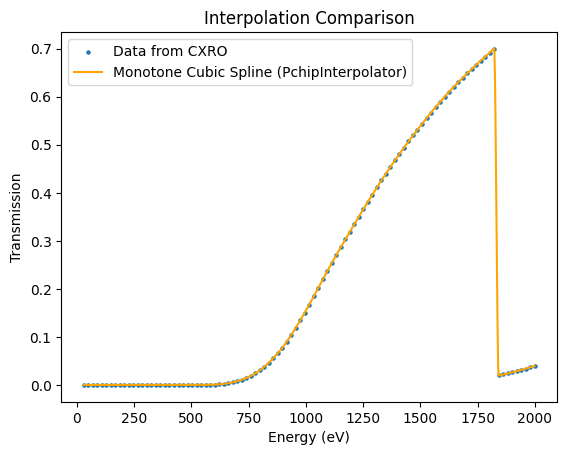

In [9]:
plt.scatter(energies, transmission, label = "Data from CXRO", s=5)
interpolated_transmission = interpolate.PchipInterpolator(energies, transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()

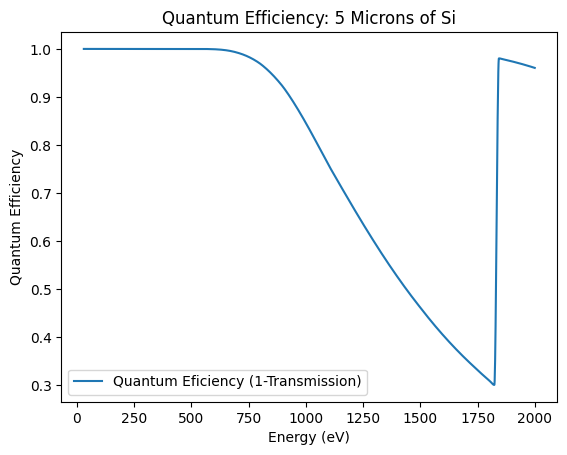

In [10]:
plt.plot(test_range, 1 - interpolated_transmission(test_range), label="Quantum Eficiency (1-Transmission)")
plt.title("Quantum Efficiency: 5 Microns of Si")
plt.xlabel("Energy (eV)")
plt.ylabel("Quantum Efficiency")
plt.legend()
plt.show()